## COVID Drivers: Modeling

This notebook models 

AGGRESSIVE_DRIVING ~
* POST_COVID
* CELL_PHONE
* IMPAIRED_DRIVER
* MATURE_DRIVER
* YOUNG_DRIVER
* FATIGUE_ASLEEP
* HIT_RUN
* UNLICENSED
* URBAN_RURALx

AGGRESSIVE_DRIVING ~
* POST_COVID
* IMPAIRED_DRIVER
* MATURE_DRIVER
* YOUNG_DRIVER
* FATIGUE_ASLEEP
* POST_COVID*IMPAIRED_DRIVER
* POST_COVID*MATURE_DRIVER
* POST_COVID*YOUNG_DRIVER
* POST_COVID*FATIGUE_ASLEEP

using logistic regression with Scikit Learn and Statsmodels

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [Logistic Regression with Cross Validation](#lgr-cv)</BR>
* [Logistic Regression with Statsmodels](#sm)</BR>
* [Logistic Regression with Cross Validation and Interaction](#lgr-cv-int)</BR>
* [Preprocessing with Interaction](#prep-int)</BR>
* [Logistic Regression with Statsmodels and Interaction](#sm-int)</BR>
* [Preprocessing for Robustness Testing](#prep-rob)</BR>
* [Robustness Testing with Statsmodels](#sm-rob)



Import packages

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import xgboost as xgb
from functools import reduce
#import prince

import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report, RocCurveDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data.csv'

### <a id='read'>Read the data</a>

Read dataset created in covid_drivers_05_Prep.ipynb

In [ ]:
df_init = pd.read_csv(path_in, low_memory=False)

In [ ]:
df_init['AGGRESSIVE_DRIVING'].sum()/df_init.shape[0]

np.float64(0.5598028680536025)

In [ ]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [ ]:
df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')]['AGGRESSIVE_DRIVING'].sum()/df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')].shape[0]

np.float64(0.5563778090234096)

In [ ]:
df = df_init.copy()

In [ ]:
df['POST_COVID_FATIGUE'] = df['POST_COVID']*df['FATIGUE_ASLEEP']

In [ ]:
df['POST_COVID_YOUNG'] = df['POST_COVID']*df['YOUNG_DRIVER']

In [ ]:
df['POST_COVID_MATURE'] = df['POST_COVID']*df['MATURE_DRIVER']

In [ ]:
df['POST_COVID_IMPAIRED'] = df['POST_COVID']*df['IMPAIRED_DRIVER']

In [ ]:
df.columns.tolist()

['CRN',
 'CRASH_DATE',
 'POST_COVID',
 'ALCOHOL_RELATED',
 'CELL_PHONE',
 'DISTRACTED',
 'DRINKING_DRIVER',
 'DRIVER_16YR',
 'DRIVER_17YR',
 'DRIVER_18YR',
 'DRIVER_19YR',
 'DRIVER_20YR',
 'DRIVER_50_64YR',
 'DRIVER_65_74YR',
 'DRIVER_75PLUS',
 'DRUGGED_DRIVER',
 'DRUG_RELATED',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'ILLEGAL_DRUG_RELATED',
 'IMPAIRED_DRIVER',
 'IMPAIRED_NONMOTORIST',
 'MARIJUANA_DRUGGED_DRIVER',
 'MARIJUANA_RELATED',
 'MATURE_DRIVER',
 'MC_DRINKING_DRIVER',
 'OPIOID_RELATED',
 'UNDERAGE_DRNK_DRV',
 'UNLICENSED',
 'YOUNG_DRIVER',
 'AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING',
 'COUNTYx',
 'URBAN_RURALx',
 'POST_COVID_FATIGUE',
 'POST_COVID_YOUNG',
 'POST_COVID_MATURE',
 'POST_COVID_IMPAIRED']

In [ ]:
df['URBAN_RURALx'].unique()

array(['Rural', 'Urbanized'], dtype=object)

### <a id='prep'>Preprocessing</a>

In [ ]:
X = df.loc[:,['POST_COVID',
 'CELL_PHONE',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'UNLICENSED',
 'URBAN_RURALx']].copy()

In [ ]:
y = df['AGGRESSIVE_DRIVING']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
categorical_cols = ['URBAN_RURALx']

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ], remainder='passthrough'
    )

In [ ]:
add_constant_func = FunctionTransformer(sm.add_constant)

### <a id='lgr-cv'>Logistic Regression with Cross Validation</a>

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
lgr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logistic_regression', LogisticRegressionCV(random_state=42, cv=skf, solver='saga', l1_ratios=[0.1, 0.25, 0.5, 0.75, 0.9], max_iter=5000))
])

In [ ]:
lgr_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1863: UserWarning: l1_ratios parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['URBAN_RURALx'])])),
                ('logistic_regression',
                 LogisticRegressionCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                      l1_ratios=[0.1, 0.25, 0.5, 0.75, 0.9],
                                      max_iter=5000, random_state=42,
                                      solver='saga'))])

In [ ]:
# Extract the trained LogisticRegressionCV model
model = lgr_pipeline.named_steps['logistic_regression']

In [ ]:
# Get Feature Names from Preprocessor - ColumnTransformer
feature_names = lgr_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [ ]:
# Get Coefficients (feature importance)
# model.coef_ shape is (1, n_features) for binary, or (n_classes, n_features)
# Using absolute value to get magnitude
importances = np.abs(model.coef_[0])

In [ ]:
# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [ ]:
print(feature_importance_df)

                       Feature  Importance
7    remainder__FATIGUE_ASLEEP    1.985435
3        remainder__CELL_PHONE    1.128570
4   remainder__IMPAIRED_DRIVER    0.527792
6      remainder__YOUNG_DRIVER    0.496979
5     remainder__MATURE_DRIVER    0.300931
8           remainder__HIT_RUN    0.176094
9        remainder__UNLICENSED    0.099017
0      cat__URBAN_RURALx_Rural    0.078224
1  cat__URBAN_RURALx_Urbanized    0.078208
2        remainder__POST_COVID    0.034167


In [ ]:
feature_names

array(['cat__URBAN_RURALx_Rural', 'cat__URBAN_RURALx_Urbanized',
       'remainder__POST_COVID', 'remainder__CELL_PHONE',
       'remainder__IMPAIRED_DRIVER', 'remainder__MATURE_DRIVER',
       'remainder__YOUNG_DRIVER', 'remainder__FATIGUE_ASLEEP',
       'remainder__HIT_RUN', 'remainder__UNLICENSED'], dtype=object)

In [ ]:
feature_names2 = []

for i, v in enumerate(feature_names):
  #print('Feature: %s' % (v))
  new = v.split('__')[1]
  if 'urban' in new.lower():
    new = new.split('_')[2].upper()
  feature_names2.append(new)

feature_names2


['RURAL',
 'URBANIZED',
 'POST_COVID',
 'CELL_PHONE',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'UNLICENSED']

In [ ]:
colors = ['teal', 'cadetblue', 'mediumaquamarine', 'seagreen', 'darkgreen', 'lightseagreen', 'skyblue', 'dodgerblue', 'royalblue', 'navy']

Feature: RURAL, Score: 0.07822
Feature: URBANIZED, Score: 0.07821
Feature: POST_COVID, Score: 0.03417
Feature: CELL_PHONE, Score: 1.12857
Feature: IMPAIRED_DRIVER, Score: 0.52779
Feature: MATURE_DRIVER, Score: 0.30093
Feature: YOUNG_DRIVER, Score: 0.49698
Feature: FATIGUE_ASLEEP, Score: 1.98544
Feature: HIT_RUN, Score: 0.17609
Feature: UNLICENSED, Score: 0.09902


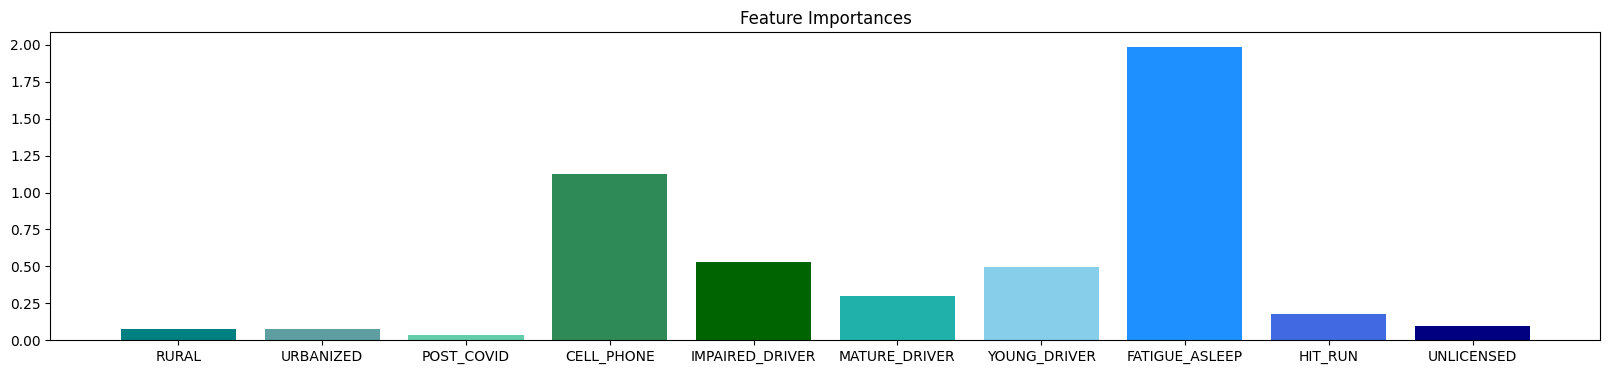

In [ ]:
for i,v in enumerate(importances):
	#print('Feature: %0d, Score: %.5f' % (i,v))
  print('Feature: %s, Score: %.5f' % (feature_names2[i],v))
# plot feature importance
plt.bar(feature_names2, importances, color=colors)
fig = plt.gcf() # Get current figure
fig.set_size_inches(20, 4)
plt.title('Feature Importances')
plt.show()

Feature: 0, Score: 0.07822
Feature: 1, Score: 0.07821
Feature: 2, Score: 0.03417
Feature: 3, Score: 1.12857
Feature: 4, Score: 0.52779
Feature: 5, Score: 0.30093
Feature: 6, Score: 0.49698
Feature: 7, Score: 1.98544
Feature: 8, Score: 0.17609
Feature: 9, Score: 0.09902


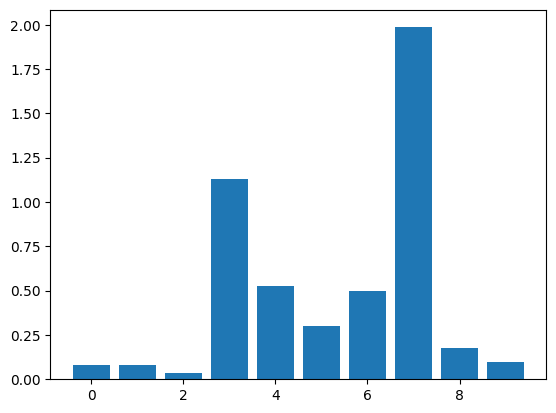

In [ ]:
for i,v in enumerate(importances):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar([x for x in range(len(importances))], importances)
plt.show()

In [ ]:
y_pred = lgr_pipeline.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 59.14%


In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

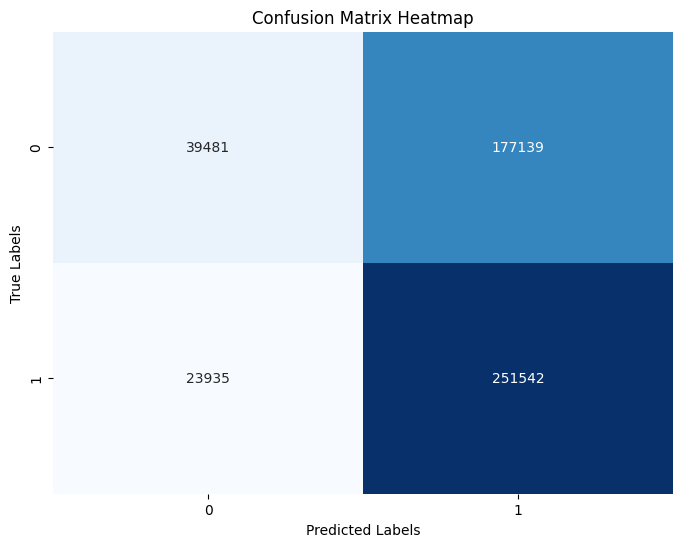

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
# Predicted probabilities for the class 1
y_pred_proba = lgr_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [ ]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [ ]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [ ]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

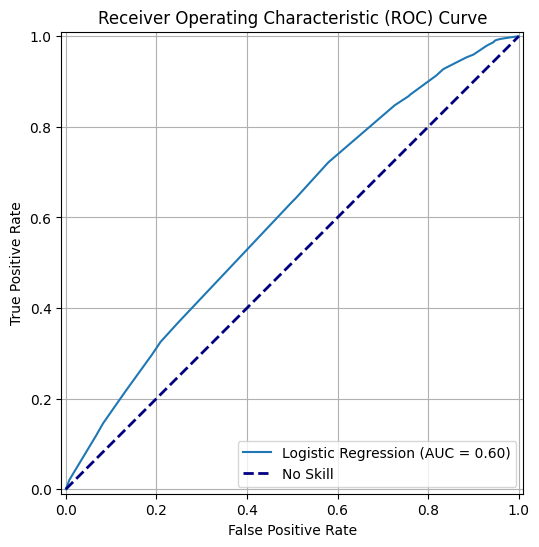

In [ ]:
# Plot the ROC curve
# Using RocCurveDisplay.from_estimator is the recommended method in modern scikit-learn
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lgr_pipeline, X_test, y_test, ax=ax, name="Logistic Regression")

# Plot the "no skill" or chance level baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No Skill')

# Customize the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

In [ ]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegressionCV'

In [ ]:
aggdrv_lgr = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [ ]:
aggdrv_lgr['LogisticRegressionCV'] = [round(x, 4) for x in aggdrv_lgr['LogisticRegressionCV']]

In [ ]:
aggdrv_lgr

,Measure,LogisticRegressionCV
0,Accuracy,0.5914
1,Precision,0.5868
2,Recall,0.9131
3,F1 Score,0.7144
4,ROC AUC,0.6012


In [ ]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.18      0.28    216620
           1       0.59      0.91      0.71    275477

    accuracy                           0.59    492097
   macro avg       0.60      0.55      0.50    492097
weighted avg       0.60      0.59      0.52    492097



### <a id='sm'>Logistic Regression with Statsmodels</a>

In [ ]:
lgr_pipeline = Pipeline(steps=[
    ('add_constant', add_constant_func),
    ('preprocessor', preprocessor)
])

In [ ]:
X_train_const = lgr_pipeline.named_steps['add_constant'].fit_transform(X_train)
X_test_const = lgr_pipeline.named_steps['add_constant'].transform(X_test)

In [ ]:
X_train_trx = lgr_pipeline.named_steps['preprocessor'].fit_transform(X_train_const)
X_test_trx = lgr_pipeline.named_steps['preprocessor'].transform(X_test_const)

In [ ]:
lgr_pipeline.named_steps['preprocessor'].get_feature_names_out()

array(['cat__URBAN_RURALx_Rural', 'cat__URBAN_RURALx_Urbanized',
       'remainder__const', 'remainder__POST_COVID',
       'remainder__CELL_PHONE', 'remainder__IMPAIRED_DRIVER',
       'remainder__MATURE_DRIVER', 'remainder__YOUNG_DRIVER',
       'remainder__FATIGUE_ASLEEP', 'remainder__HIT_RUN',
       'remainder__UNLICENSED'], dtype=object)

In [ ]:
feature_names = lgr_pipeline.named_steps['preprocessor'].get_feature_names_out()
X_train_final = pd.DataFrame(X_train_trx, columns=feature_names)
X_test_final = pd.DataFrame(X_test_trx, columns=feature_names)

In [ ]:
X_train_final['remainder__const'].unique()

array([1.])

In [ ]:
model = sm.Logit(y_train.values, X_train_final)

In [ ]:
result = model.fit(maxiter=1000)

         Current function value: 0.666000
         Iterations: 1000


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:              1968387
Model:                          Logit   Df Residuals:                  1968376
Method:                           MLE   Df Model:                           10
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                 0.02912
Time:                        00:34:20   Log-Likelihood:            -1.3109e+06
converged:                      False   LL-Null:                   -1.3503e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
cat__URBAN_RURALx_Rural        -0.0128   7.81e+04  -1.64e-07      1.000   -1.53e+05    1.53e+05
cat__URBAN_RURALx_Urbanized     0.1436   7.81e+04   1.84e-06      1.000   -1.53e

### <a id='prep-int'>Preprocessing with Interaction</a>

In [ ]:
X = df.loc[:,['POST_COVID',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
  'POST_COVID_IMPAIRED',
  'POST_COVID_MATURE',
  'POST_COVID_YOUNG',
  'POST_COVID_FATIGUE',]].copy()

In [ ]:
y = df['AGGRESSIVE_DRIVING']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
categorical_cols = ['URBAN_RURALx']

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ], remainder='passthrough'
    )

In [ ]:
add_constant_func = FunctionTransformer(sm.add_constant)

### <a id='lgr-cv-int'>Logistic Regression with Cross Validation and Interaction</a>

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
lgr_pipeline = Pipeline(steps=[
    ('logistic_regression', LogisticRegressionCV(random_state=42, cv=skf, solver='saga', l1_ratios=[0.1, 0.25, 0.5, 0.75, 0.9], max_iter=5000))
])

In [ ]:
lgr_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1863: UserWarning: l1_ratios parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Pipeline(steps=[('logistic_regression',
                 LogisticRegressionCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                      l1_ratios=[0.1, 0.25, 0.5, 0.75, 0.9],
                                      max_iter=5000, random_state=42,
                                      solver='saga'))])

In [ ]:
# Extract the trained LogisticRegressionCV model
model = lgr_pipeline.named_steps['logistic_regression']

In [ ]:
feature_names = lgr_pipeline.named_steps['logistic_regression'].feature_names_in_

In [ ]:
# Get Coefficients (feature importance)
# model.coef_ shape is (1, n_features) for binary, or (n_classes, n_features)
# Using absolute value to get magnitude
importances = np.abs(model.coef_[0])

In [ ]:
# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [ ]:
print(feature_importance_df)

               Feature  Importance
4       FATIGUE_ASLEEP    2.051614
1      IMPAIRED_DRIVER    0.502503
3         YOUNG_DRIVER    0.481217
2        MATURE_DRIVER    0.304962
5  POST_COVID_IMPAIRED    0.271782
6    POST_COVID_MATURE    0.082482
7     POST_COVID_YOUNG    0.074151
0           POST_COVID    0.040012
8   POST_COVID_FATIGUE    0.003796


In [ ]:
colors = ['teal', 'cadetblue', 'mediumaquamarine', 'seagreen', 'darkseagreen', 'lightseagreen', 'skyblue', 'dodgerblue', 'royalblue', 'navy']

Feature: POST_COVID, Score: 0.04001
Feature: IMPAIRED_DRIVER, Score: 0.50250
Feature: MATURE_DRIVER, Score: 0.30496
Feature: YOUNG_DRIVER, Score: 0.48122
Feature: FATIGUE_ASLEEP, Score: 2.05161
Feature: POST_COVID_IMPAIRED, Score: 0.27178
Feature: POST_COVID_MATURE, Score: 0.08248
Feature: POST_COVID_YOUNG, Score: 0.07415
Feature: POST_COVID_FATIGUE, Score: 0.00380


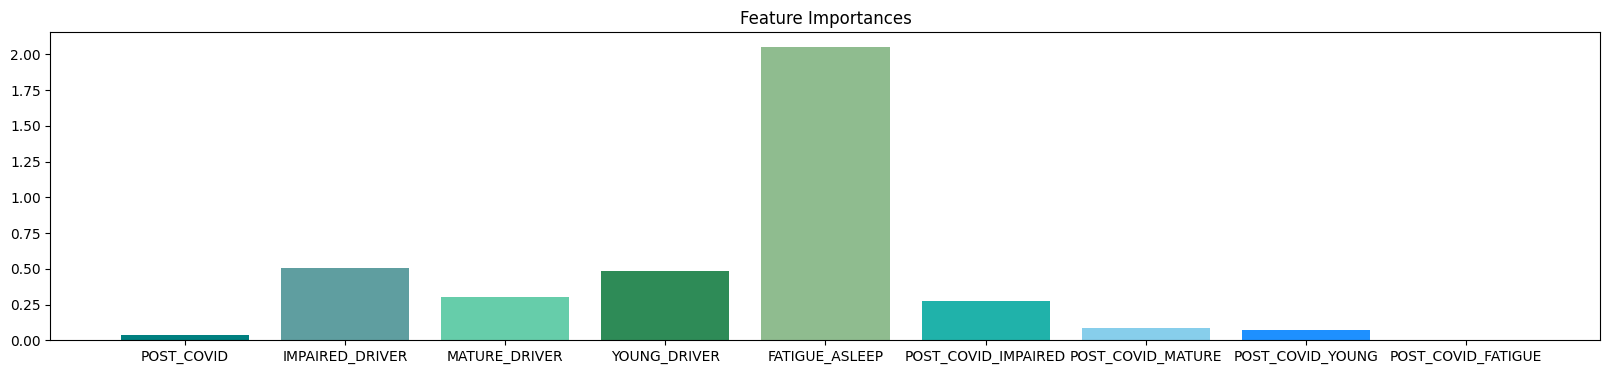

In [ ]:
for i,v in enumerate(importances):
	#print('Feature: %0d, Score: %.5f' % (i,v))
  print('Feature: %s, Score: %.5f' % (feature_names[i],v))
# plot feature importance
plt.bar(feature_names, importances, color=colors)
fig = plt.gcf() # Get current figure
fig.set_size_inches(20, 4)
plt.title('Feature Importances')
plt.show()

Feature: POST_COVID, Score: 0.04001
Feature: IMPAIRED_DRIVER, Score: 0.50250
Feature: MATURE_DRIVER, Score: 0.30496
Feature: YOUNG_DRIVER, Score: 0.48122
Feature: FATIGUE_ASLEEP, Score: 2.05161
Feature: POST_COVID_IMPAIRED, Score: 0.27178
Feature: POST_COVID_MATURE, Score: 0.08248
Feature: POST_COVID_YOUNG, Score: 0.07415
Feature: POST_COVID_FATIGUE, Score: 0.00380


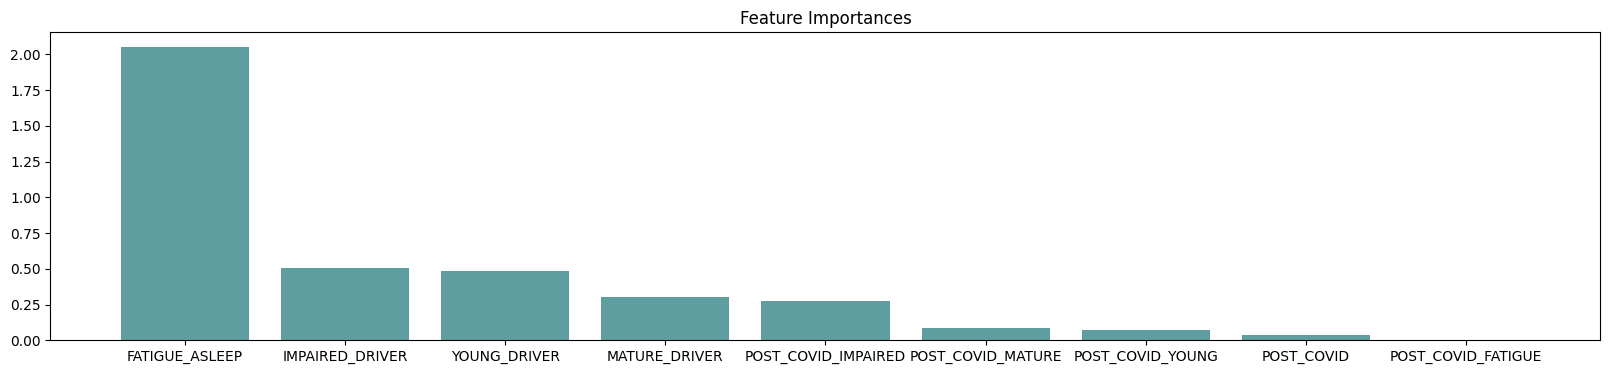

In [ ]:
for i,v in enumerate(importances):
	#print('Feature: %0d, Score: %.5f' % (i,v))
  print('Feature: %s, Score: %.5f' % (feature_names[i],v))
# plot feature importance
#plt.bar(feature_names, importances, color='cadetblue')
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='cadetblue')
fig = plt.gcf() # Get current figure
fig.set_size_inches(20, 4)
plt.title('Feature Importances')
plt.show()

Feature: 0, Score: 0.04001
Feature: 1, Score: 0.50250
Feature: 2, Score: 0.30496
Feature: 3, Score: 0.48122
Feature: 4, Score: 2.05161
Feature: 5, Score: 0.27178
Feature: 6, Score: 0.08248
Feature: 7, Score: 0.07415
Feature: 8, Score: 0.00380


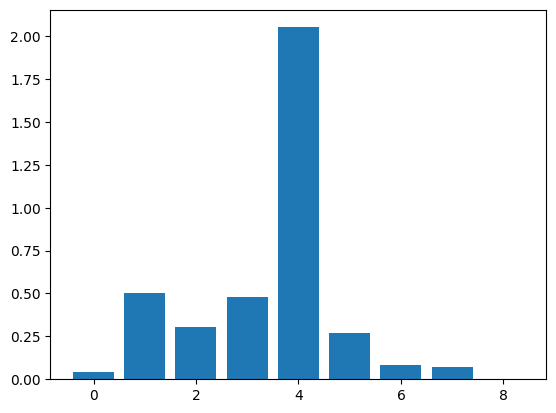

In [ ]:
for i,v in enumerate(importances):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar([x for x in range(len(importances))], importances)
plt.show()

In [ ]:
y_pred = lgr_pipeline.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 58.92%


In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

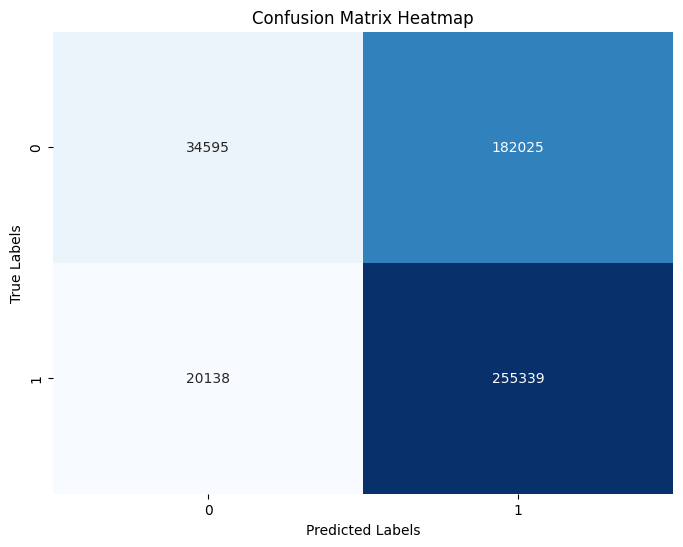

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
# Predicted probabilities for the class 1
y_pred_proba = lgr_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [ ]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [ ]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [ ]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

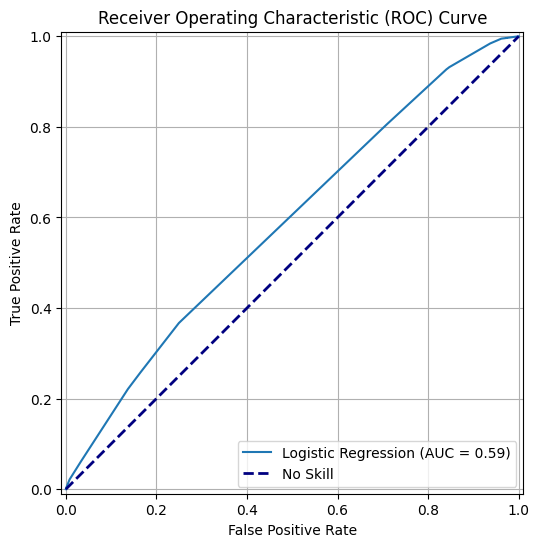

In [ ]:
# Plot the ROC curve
# Using RocCurveDisplay.from_estimator is the recommended method in modern scikit-learn
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lgr_pipeline, X_test, y_test, ax=ax, name="Logistic Regression")

# Plot the "no skill" or chance level baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No Skill')

# Customize the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

In [ ]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegressionCV'

In [ ]:
aggdrv_lgr = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [ ]:
aggdrv_lgr['LogisticRegressionCV'] = [round(x, 4) for x in aggdrv_lgr['LogisticRegressionCV']]

In [ ]:
aggdrv_lgr

,Measure,LogisticRegressionCV
0,Accuracy,0.5892
1,Precision,0.5838
2,Recall,0.9269
3,F1 Score,0.7164
4,ROC AUC,0.5871


In [ ]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.16      0.25    216620
           1       0.58      0.93      0.72    275477

    accuracy                           0.59    492097
   macro avg       0.61      0.54      0.49    492097
weighted avg       0.61      0.59      0.51    492097



### <a id='sm-int'>Logistic Regression with Statsmodels and Interaction</a>

In [ ]:
X_train = sm.add_constant(X_train)

In [ ]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y_train.values, X_train)

In [ ]:
result = model.fit()

Optimization terminated successfully.
         Current function value: 0.668236
         Iterations 6


In [ ]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:              1968387
Model:                          Logit   Df Residuals:                  1968377
Method:                           MLE   Df Model:                            9
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.02586
Time:                        02:23:38   Log-Likelihood:            -1.3153e+06
converged:                       True   LL-Null:                   -1.3503e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.1960      0.002     92.660      0.000       0.192       0.200
POST_COVID             -0.0401      0.005     -8.909      0.000      -0.049      -0.031
IMPAIRED_DRIVER 

In [ ]:
importances = result.params.abs().sort_values(ascending=False)
print(importances.sort_values(ascending=False))

FATIGUE_ASLEEP         2.063589
IMPAIRED_DRIVER        0.502693
YOUNG_DRIVER           0.481402
MATURE_DRIVER          0.305074
POST_COVID_IMPAIRED    0.272253
const                  0.196039
POST_COVID_MATURE      0.082559
POST_COVID_YOUNG       0.074137
POST_COVID             0.040103
POST_COVID_FATIGUE     0.015919
dtype: float64


In [ ]:
importances

,0
FATIGUE_ASLEEP,2.063589
IMPAIRED_DRIVER,0.502693
YOUNG_DRIVER,0.481402
MATURE_DRIVER,0.305074
POST_COVID_IMPAIRED,0.272253
const,0.196039
POST_COVID_MATURE,0.082559
POST_COVID_YOUNG,0.074137
POST_COVID,0.040103
POST_COVID_FATIGUE,0.015919


In [ ]:
coeffs = result.params.abs().values
feature_names = result.params.index

In [ ]:
# Create a clean DataFrame
summary_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs}).sort_values(by='Coefficient', ascending=False)
print(summary_df)

               Feature  Coefficient
5       FATIGUE_ASLEEP     2.063589
2      IMPAIRED_DRIVER     0.502693
4         YOUNG_DRIVER     0.481402
3        MATURE_DRIVER     0.305074
6  POST_COVID_IMPAIRED     0.272253
0                const     0.196039
7    POST_COVID_MATURE     0.082559
8     POST_COVID_YOUNG     0.074137
1           POST_COVID     0.040103
9   POST_COVID_FATIGUE     0.015919


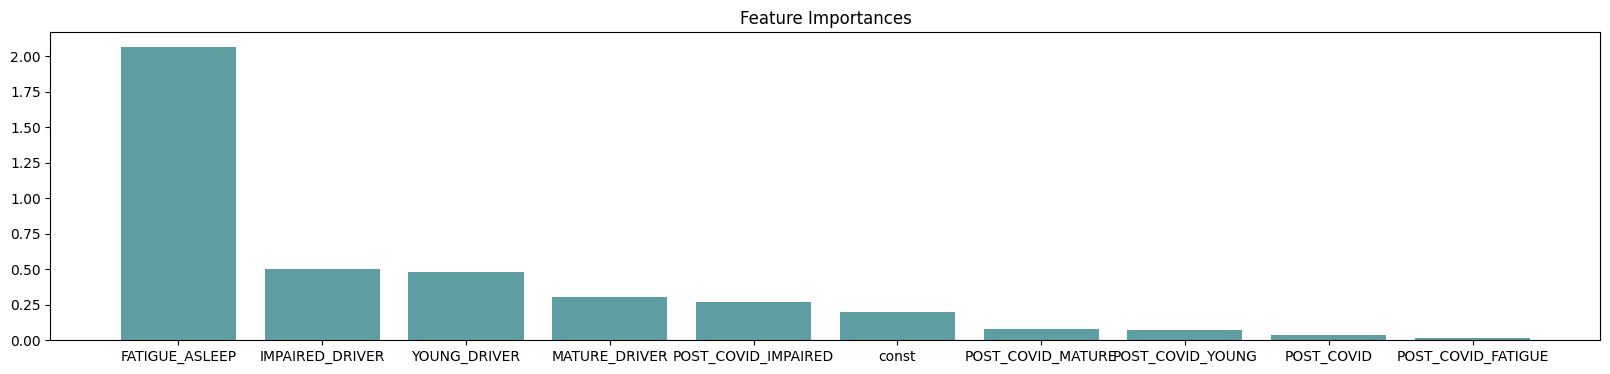

In [ ]:
# plot feature importance
#plt.bar(feature_names, importances, color='cadetblue')
plt.bar(summary_df['Feature'], summary_df['Coefficient'], color='cadetblue')
fig = plt.gcf() # Get current figure
fig.set_size_inches(20, 4)
plt.title('Feature Importances')
plt.show()

### <a id='prep-rob'>Preprocessing for Robustness Testing</a>

In [ ]:
#df1 = df.loc[df['URBAN_RURALx']=='Urbanized'].copy()
df1 = df.loc[(df['CRASH_DATE'] >= pd.to_datetime('2019-03-01', format='%Y-%m-%d')) & (df['CRASH_DATE'] < pd.to_datetime('2021-03-01', format='%Y-%m-%d'))].copy()

In [ ]:
#df2 = df.loc[df['URBAN_RURALx']=='Rural'].copy()
df2 = df.loc[df['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')].copy()

In [ ]:
#df.shape[0] == df1.shape[0] + df2.shape[0]

In [ ]:
X1 = df1.loc[:,['POST_COVID',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
  'POST_COVID_IMPAIRED',
  'POST_COVID_MATURE',
  'POST_COVID_YOUNG',
  'POST_COVID_FATIGUE']].copy()

In [ ]:
X2 = df2.loc[:,['POST_COVID',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
  'POST_COVID_IMPAIRED',
  'POST_COVID_MATURE',
  'POST_COVID_YOUNG',
  'POST_COVID_FATIGUE']].copy()

In [ ]:
y1 = df1['AGGRESSIVE_DRIVING']
y2 = df2['AGGRESSIVE_DRIVING']

In [ ]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=42)

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=42)

In [ ]:
add_constant_func = FunctionTransformer(sm.add_constant)

### <a id='sm-rob'>Robustness Testing with Statsmodels</a>

In [ ]:
X1_train = sm.add_constant(X1_train)

In [ ]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y1_train.values, X1_train)

In [ ]:
result1 = model.fit()

Optimization terminated successfully.
         Current function value: 0.669616
         Iterations 6


In [ ]:
print(result1.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               180806
Model:                          Logit   Df Residuals:                   180796
Method:                           MLE   Df Model:                            9
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.02695
Time:                        01:03:29   Log-Likelihood:            -1.2107e+05
converged:                       True   LL-Null:                   -1.2442e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.1786      0.008     21.517      0.000       0.162       0.195
POST_COVID             -0.0538      0.012     -4.410      0.000      -0.078      -0.030
IMPAIRED_DRIVER 

In [ ]:
importances1 = result1.params.abs().sort_values(ascending=False)
print(importances1.sort_values(ascending=False))

FATIGUE_ASLEEP         1.935538
IMPAIRED_DRIVER        0.701241
YOUNG_DRIVER           0.513298
MATURE_DRIVER          0.337754
const                  0.178555
POST_COVID             0.053809
POST_COVID_IMPAIRED    0.042989
POST_COVID_FATIGUE     0.042277
POST_COVID_MATURE      0.023328
POST_COVID_YOUNG       0.005238
dtype: float64


In [ ]:
X2_train = sm.add_constant(X2_train)

In [ ]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y2_train.values, X2_train)

In [ ]:
result2 = model.fit()

Optimization terminated successfully.
         Current function value: 0.666544
         Iterations 6


In [ ]:
print(result2.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               940504
Model:                          Logit   Df Residuals:                   940494
Method:                           MLE   Df Model:                            9
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.02946
Time:                        01:03:37   Log-Likelihood:            -6.2689e+05
converged:                       True   LL-Null:                   -6.4592e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2022      0.004     55.513      0.000       0.195       0.209
POST_COVID             -0.0482      0.005     -8.935      0.000      -0.059      -0.038
IMPAIRED_DRIVER 

In [ ]:
importances2 = result2.params.abs().sort_values(ascending=False)
print(importances2.sort_values(ascending=False))

FATIGUE_ASLEEP         1.999961
IMPAIRED_DRIVER        0.662283
YOUNG_DRIVER           0.480780
MATURE_DRIVER          0.332837
const                  0.202242
POST_COVID_IMPAIRED    0.102996
POST_COVID_YOUNG       0.076399
POST_COVID_MATURE      0.055449
POST_COVID_FATIGUE     0.050394
POST_COVID             0.048155
dtype: float64


In [ ]:
print(importances1.sort_values(ascending=False))

FATIGUE_ASLEEP         1.935538
IMPAIRED_DRIVER        0.701241
YOUNG_DRIVER           0.513298
MATURE_DRIVER          0.337754
const                  0.178555
POST_COVID             0.053809
POST_COVID_IMPAIRED    0.042989
POST_COVID_FATIGUE     0.042277
POST_COVID_MATURE      0.023328
POST_COVID_YOUNG       0.005238
dtype: float64
